<table border=0 width="100%"><tr><td><p align="left"><img src="..\img\logo.png" align="left" width=300></p></td><td><font size=5><B> LLM_based Agents (郑海超)</B></font></td></tr></table>

# 内容

- 智能体工作模式
- Langchain智能体框架
- ReAct模式的智能体设计

# TradExpert: Revolutionizing Trading with Mixture of Expert LLMs

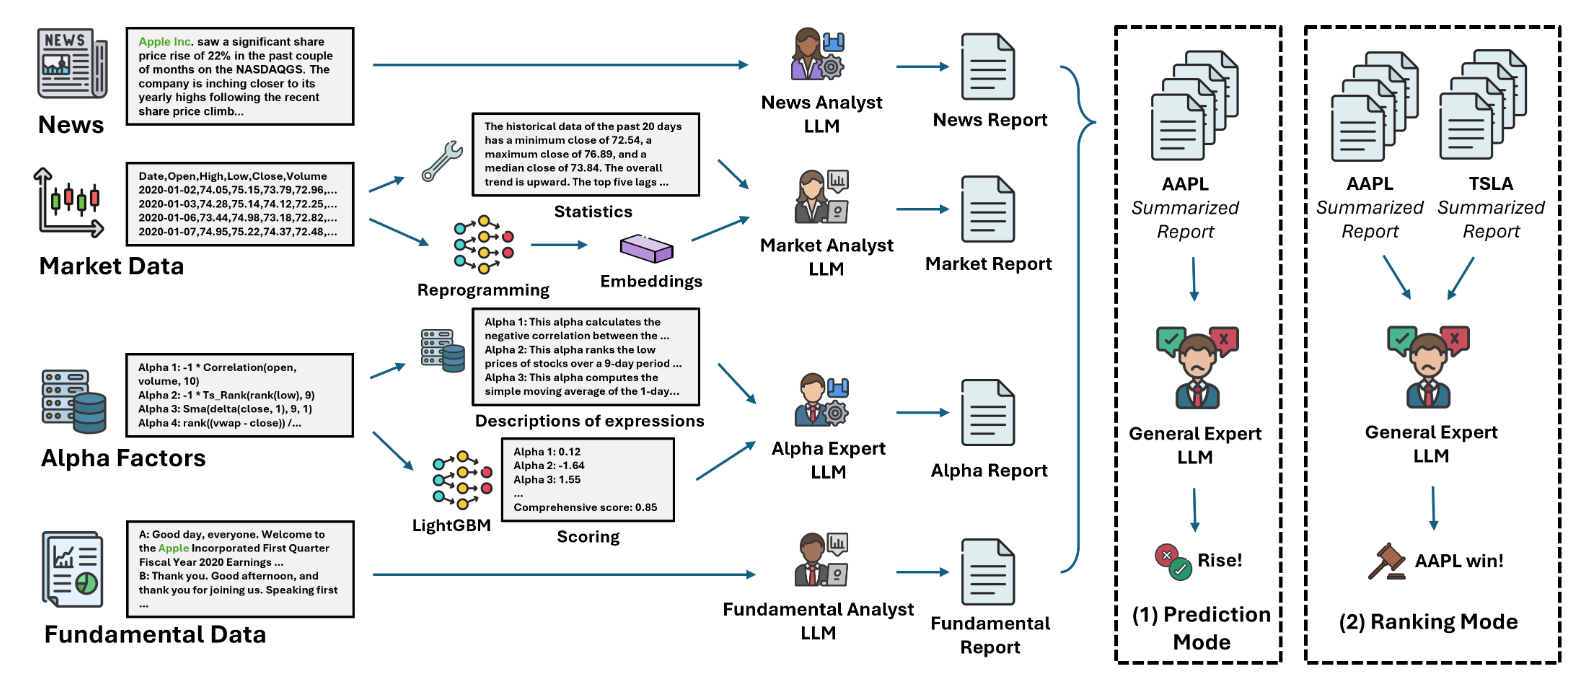

# LLM_based agents基本工作思路

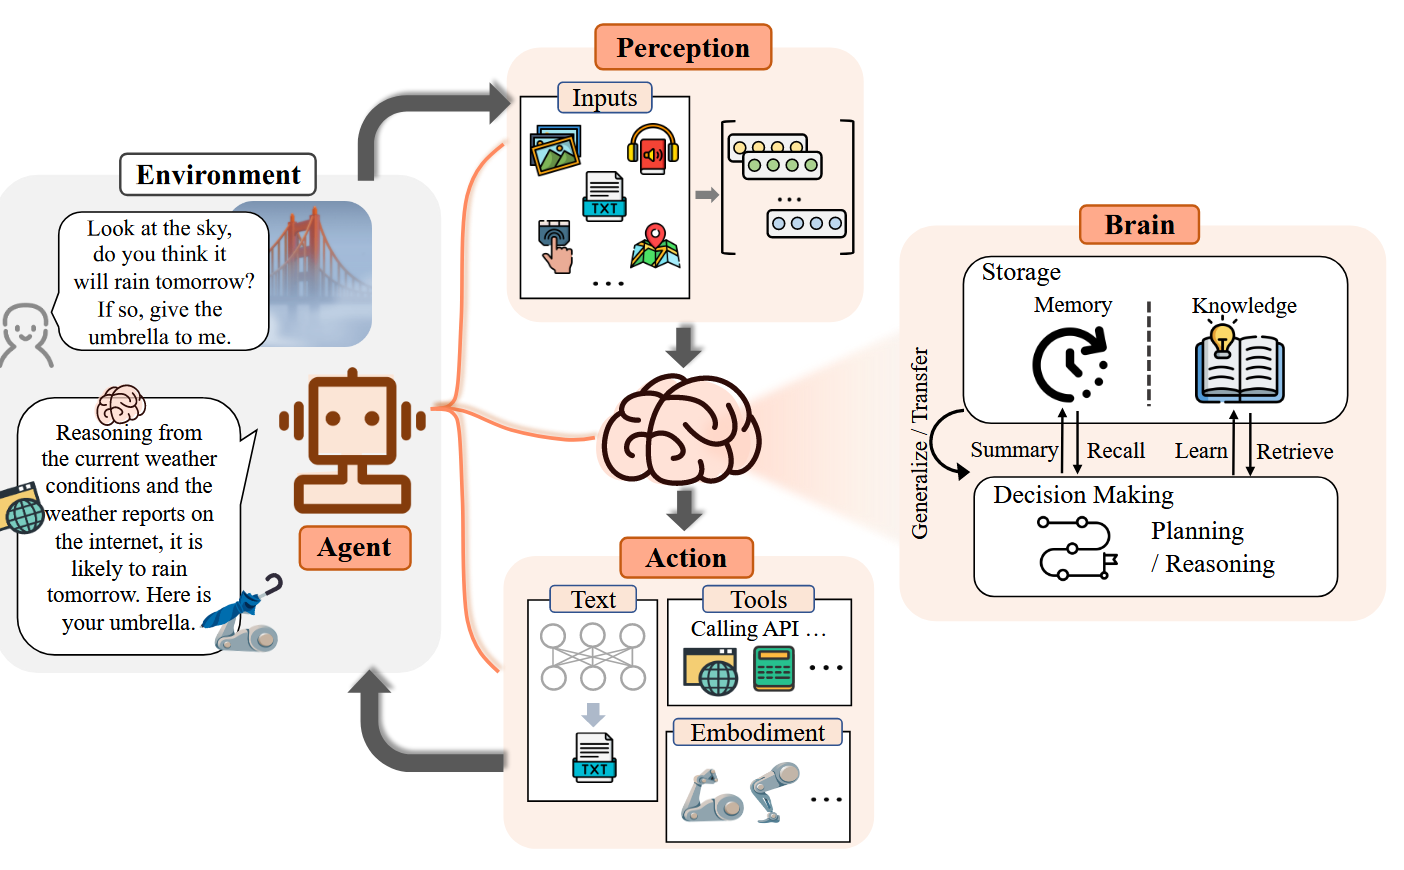

# 智能体ReAct工作模式

- Reasoning + Acting


ReAct 是一种将大语言模型的推理能力与外部工具的行动能力相结合的强大范式。它通过结构化的“思考-行动-观察”循环，使AI智能体能够以更可靠、更透明、更强大的方式解决需要动态信息和复杂操作的真实世界问题，是当前构建高级AI应用的核心设计模式之一。

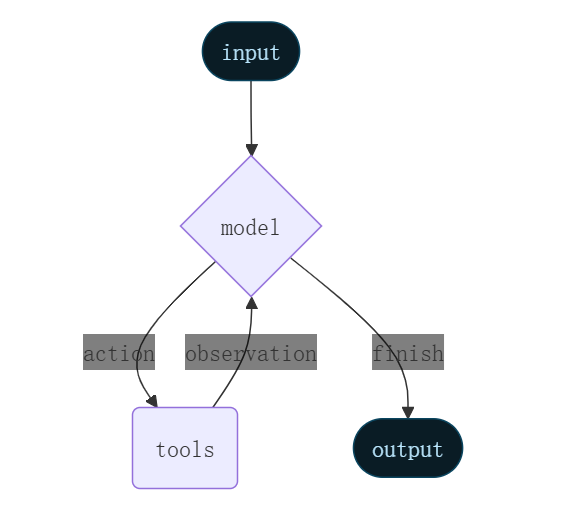

# Langchain智能体设计框架

## 智能体设计框架
- Langchain
- LangGraph
- AutoGen

## LangChain设计框架的目标

LangChain is driven by a few core beliefs:
- Large Language Models (LLMs) are great, powerful new technology.
- LLMs are even better when you combine them with external sources of data.
- LLMs will transform what the applications of the future look like. Specifically, the applications of the future will look more and more agentic.
- It is still very early on in that transformation.
- While it’s easy to build a prototype of those agentic applications, it’s still really hard to build agents that are reliable enough to put into production.

With LangChain, we have two core focuses:

- We want to enable developers to build with the best models.

- We want to make it easy to use models to orchestrate more complex flows that interact with other data and computation.

##  设计ReAct模式的智能体

### 定义智能体大脑

In [2]:
from dotenv import load_dotenv
import os

load_dotenv(override=True)
Doubao_API_KEY = os.getenv('Doubao_API_KEY') 

from langchain_openai import ChatOpenAI

model = ChatOpenAI(
    model="doubao-1-5-pro-32k-250115",  # Specify a model available on OpenRouter
    api_key=Doubao_API_KEY, 
    base_url="https://ark.cn-beijing.volces.com/api/v3",
)

### 设计工具

In [3]:
import tushare as ts

# 下面这个token本学期大家可以使用，如果同时使用，可能会出现调研频次限制
token = "d60077d056be2a4e38f3c75c18ba317cb41ae04bf734b259ee08fcb6"

ts.set_token(token=token)

pro = ts.pro_api()

In [5]:
import tushare as ts
import pandas as pd
from datetime import datetime, timedelta
from langchain.tools import tool

# 构建一个函数，获取最近1天的股票因子数据
@tool
def get_recent_stk_factor(ts_code: str) -> str:
      """  get the stock technical indicators.
      Args:
          ts_code: code for a stock, like: 600000.SH
     Returns:
         the technical indicators
      """
      # 获取当前日期
      end_date = datetime.now().strftime('%Y%m%d')
      # 计算最近5天的日期
      start_date = (datetime.now() - timedelta(days=5)).strftime('%Y%m%d')
      # 调用tushare接口获取股票因子数据
      df = pro.stk_factor(
        ts_code=ts_code, 
        start_date=start_date, 
        end_date=end_date, 
        fields='ts_code,trade_date,macd,kdj_k,kdj_d,kdj_j,rsi_6,rsi_12,rsi_24, macd_dif,macd_dea')
      return df.to_json(orient='records')

In [6]:
get_recent_stk_factor.invoke("600519.SH")

'[{"ts_code":"600519.SH","trade_date":"20251224","macd":3.37,"kdj_k":67.371,"kdj_d":70.671,"kdj_j":60.77,"rsi_6":43.19,"rsi_12":44.701,"rsi_24":45.791,"macd_dif":-4.53,"macd_dea":-6.215},{"ts_code":"600519.SH","trade_date":"20251223","macd":4.196,"kdj_k":79.895,"kdj_d":72.321,"kdj_j":95.042,"rsi_6":56.578,"rsi_12":49.523,"rsi_24":47.704,"macd_dif":-4.538,"macd_dea":-6.636},{"ts_code":"600519.SH","trade_date":"20251222","macd":3.938,"kdj_k":80.456,"kdj_d":68.534,"kdj_j":104.3,"rsi_6":57.43,"rsi_12":49.806,"rsi_24":47.814,"macd_dif":-5.191,"macd_dea":-7.16}]'

In [7]:
from langchain.agents import create_agent

# 3. 创建工具列表
tools = [get_recent_stk_factor]

# 4. 创建智能体
finance_agent = create_agent(
    model=model,
    tools=tools,
    system_prompt="You are a helpful assistant. Use the search tool to find stock technical indicators when needed."
)

In [8]:
# 流式输出方式
for event in finance_agent.stream(
    {"messages": [{"role": "user", "content": "贵州茅台（股票代码：600519.SH）接下来股价走势如何?预测接下来一个交易日股价的波动方向，务必输出上涨和下跌的概率（JSON， 格式：{'上涨概率': 0.6, '下跌概率': 0.4}）"}]},
    stream_mode="values",
):
    event["messages"][-1].pretty_print()

================================ Human Message =================================

贵州茅台（股票代码：600519.SH）接下来股价走势如何?预测接下来一个交易日股价的波动方向，务必输出上涨和下跌的概率（JSON， 格式：{'上涨概率': 0.6, '下跌概率': 0.4}）
================================== Ai Message ==================================

用户想预测贵州茅台接下来一个交易日股价的波动方向及上涨下跌概率，调用 get_recent_stk_factor 函数获取股票技术指标辅助分析。
Tool Calls:
  get_recent_stk_factor (call_783wnhqo2rbrtmez0c17oj3t)
 Call ID: call_783wnhqo2rbrtmez0c17oj3t
  Args:
    ts_code: 600519.SH
================================= Tool Message =================================
Name: get_recent_stk_factor

[{"ts_code":"600519.SH","trade_date":"20251224","macd":3.37,"kdj_k":67.371,"kdj_d":70.671,"kdj_j":60.77,"rsi_6":43.19,"rsi_12":44.701,"rsi_24":45.791,"macd_dif":-4.53,"macd_dea":-6.215},{"ts_code":"600519.SH","trade_date":"20251223","macd":4.196,"kdj_k":79.895,"kdj_d":72.321,"kdj_j":95.042,"rsi_6":56.578,"rsi_12":49.523,"rsi_24":47.704,"macd_dif":-4.538,"macd_dea":-6.636},{"ts_code":"600519.SH","trade_date":"2025

In [9]:
response = finance_agent.invoke(
    {"messages": [{"role": "user", "content": "贵州茅台（股票代码：600519.SH）接下来股价走势如何?"}]}
)

# 获取最终回答
print(response["messages"][-1].content)

股票价格的走势是非常复杂且难以精准预测的，不过我们可以结合获取到的贵州茅台（600519.SH）的部分技术指标来进行一定的分析。

### 1. MACD指标分析
MACD（指数平滑异同移动平均线）由 MACD 柱线（MACD）、DIF 线（MACD_DIF）和 DEA 线（MACD_DEA）组成。从数据来看，2025 年 12 月 22 - 24 日，MACD 柱线分别为 3.938、4.196、3.37，其数值先升后降；DIF 线分别为 -5.191、 -4.538、 -4.53，呈现上升趋势；DEA 线分别为 -7.16、 -6.636、 -6.215，同样呈上升趋势。当 DIF 线向上穿过 DEA 线时为金叉，是买入信号；反之，当 DIF 线向下穿过 DEA 线时为死叉，是卖出信号。当前虽然 DIF 和 DEA 都在上升，但均为负值，说明目前可能处于相对弱势状态，但有转强的迹象。

### 2. KDJ指标分析
KDJ（随机指标）由 K 线（KDJ_K）、D 线（KDJ_D）和 J 线（KDJ_J）组成。2025 年 12 月 22 - 24 日，K 线数值分别为 80.456、79.895、67.371，呈下降趋势；D 线数值分别为 68.534、72.321、70.671，先升后降；J 线数值分别为 104.3、95.042、60.77，下降明显。一般来说，KDJ 指标在 80 以上为超买区，20 以下为超卖区。此前 K、J 线处于超买区，之后数值下降，可能意味着股价短期内有回调的需求。

### 3. RSI指标分析
RSI（相对强弱指标）有不同的周期，这里给出了 6 日（RSI_6）、12 日（RSI_12）和 24 日（RSI_24）的数值。2025 年 12 月 22 - 24 日，RSI_6 数值分别为 57.43、56.578、43.19，呈下降趋势；RSI_12 数值分别为 49.806、49.523、44.701，下降；RSI_24 数值分别为 47.814、47.704、45.791，也呈下降趋势。RSI 指标在 70 以上为超买区，30 以下为超卖区。目前各周期 RSI 数值均有所下降，且逐渐接近超卖区，反映出股价近期走弱。

综合以上各项技术指标来看，贵州茅台短期内股价可能面临一定的回调压力，但由于 MACD 指标显示有转强迹象，从

## 智能体设计平台（根据需要自学）

- https://agent.swufe.edu.cn/
- https://www.coze.cn/